# Importing Libraries

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"

PALETTE = ["#2EC4B6", "#E71D36", "#FF9F1C", "#4361EE", "#7209B7"]
sns.set_style("darkgrid")

print("All libraries imported successfully.")

All libraries imported successfully.


# Read Data

In [54]:
df=pd.read_csv("data/raw/dataset.csv")
df.columns=df.columns.str.strip()

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (50000, 20)


,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


Drop Loan Id

In [55]:
df.drop(columns=['customer_id'],inplace=True)
print("loan_id dropped. New shape:", df.shape)

loan_id dropped. New shape: (50000, 19)


# Basic Data Info


In [56]:
print("=" * 55)
print("DATASET INFO")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print("STATISTICAL SUMMARY")
print("=" * 55)
df.describe().T

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      50000 non-null  int64  
 1   occupation_status        50000 non-null  object 
 2   years_employed           50000 non-null  float64
 3   annual_income            50000 non-null  int64  
 4   credit_score             50000 non-null  int64  
 5   credit_history_years     50000 non-null  float64
 6   savings_assets           50000 non-null  int64  
 7   current_debt             50000 non-null  int64  
 8   defaults_on_file         50000 non-null  int64  
 9   delinquencies_last_2yrs  50000 non-null  int64  
 10  derogatory_marks         50000 non-null  int64  
 11  product_type             50000 non-null  object 
 12  loan_intent              50000 non-null  object 
 13  loan_amount              50000 non-null  int64  
 14  interest_

,count,mean,std,min,25%,50%,75%,max
age,50000.0,34.957060,11.118603,18.000,26.000,35.000,43.00000,70.000
years_employed,50000.0,7.454868,7.612097,0.000,1.300,4.900,11.40000,39.900
annual_income,50000.0,50062.892040,32630.501014,15000.000,27280.500,41607.500,62723.25000,250000.000
credit_score,50000.0,643.614820,64.731518,348.000,600.000,643.000,687.00000,850.000
credit_history_years,50000.0,8.168274,7.207552,0.000,2.000,6.100,12.60000,30.000
savings_assets,50000.0,3595.619400,13232.399398,0.000,130.000,568.000,2271.00000,300000.000
current_debt,50000.0,14290.442220,13243.757493,60.000,5581.000,10385.000,18449.25000,163344.000
defaults_on_file,50000.0,0.053480,0.224991,0.000,0.000,0.000,0.00000,1.000
delinquencies_last_2yrs,50000.0,0.554640,0.845050,0.000,0.000,0.000,1.00000,9.000
derogatory_marks,50000.0,0.147640,0.412996,0.000,0.000,0.000,0.00000,4.000


# Missing Values

In [57]:
missing = df.isnull().sum()
percent = (missing / len(df)) * 100

missing_df=pd.DataFrame({
    "Missing Values": missing,
    "Percentage": percent
})
print(missing_df)

                         Missing Values  Percentage
age                                   0         0.0
occupation_status                     0         0.0
years_employed                        0         0.0
annual_income                         0         0.0
credit_score                          0         0.0
credit_history_years                  0         0.0
savings_assets                        0         0.0
current_debt                          0         0.0
defaults_on_file                      0         0.0
delinquencies_last_2yrs               0         0.0
derogatory_marks                      0         0.0
product_type                          0         0.0
loan_intent                           0         0.0
loan_amount                           0         0.0
interest_rate                         0         0.0
debt_to_income_ratio                  0         0.0
loan_to_income_ratio                  0         0.0
payment_to_income_ratio               0         0.0
loan_status 

# Fix negative assets value

In [58]:
negative_assets = df[df["savings_assets"] < 0]
print(f"Rows with negative savings_assets: {len(negative_assets)}")

df = df[df["savings_assets"] >= 0]
print(f"Dataset shape after fix: {df.shape}")

Rows with negative savings_assets: 0
Dataset shape after fix: (50000, 19)


# Target Variable Distribution

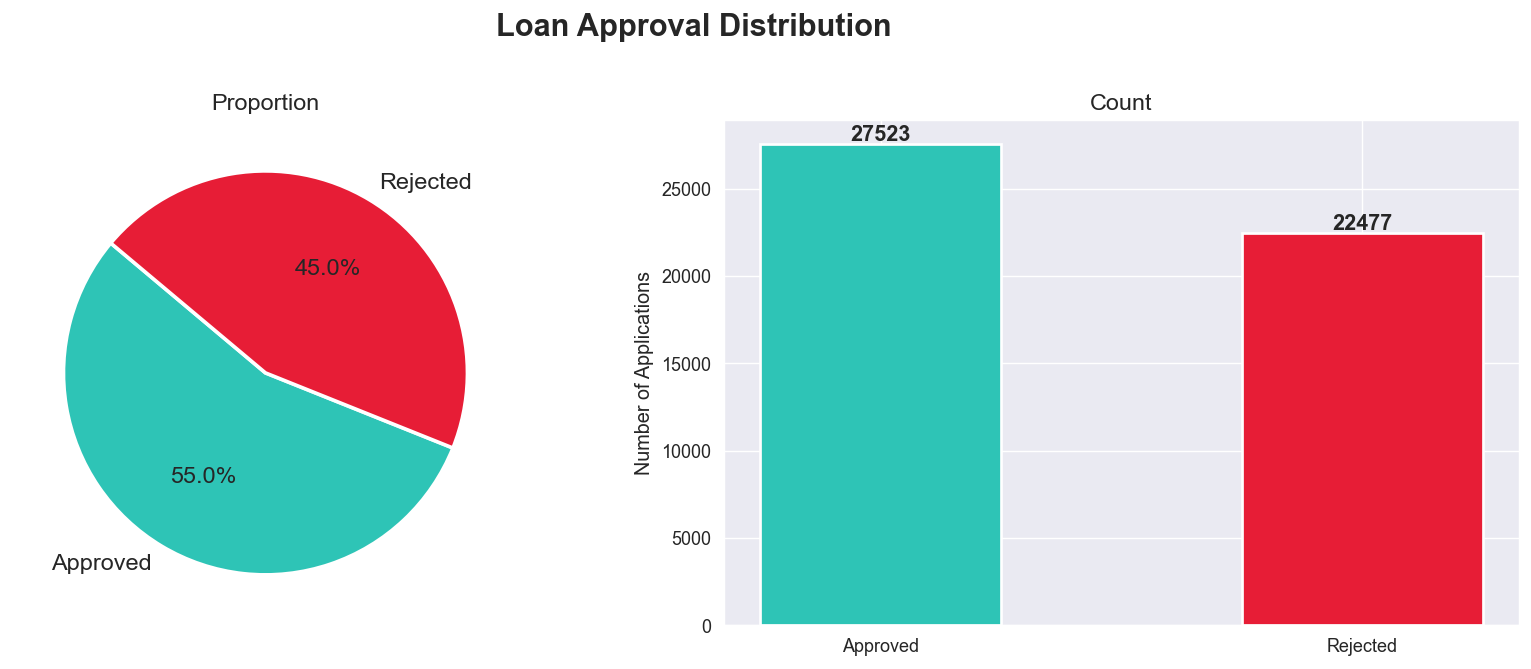

In [59]:
target_col = "loan_status"

counts = df[target_col].value_counts()


label_map = {0: "Rejected", 1: "Approved"}
counts.index = counts.index.map(label_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Loan Approval Distribution", fontsize=17, fontweight="bold", y=1.02)

# Pie chart
axes[0].pie(counts.values, labels=counts.index,
            colors=[PALETTE[0], PALETTE[1]],
            autopct="%1.1f%%", startangle=140,
            wedgeprops=dict(edgecolor="white", linewidth=2),
            textprops={"fontsize": 13})
axes[0].set_title("Proportion", fontsize=13)

# Bar chart 
axes[1].bar(counts.index, counts.values,
            color=[PALETTE[0], PALETTE[1]],
            edgecolor="white", linewidth=1.5, width=0.5)

axes[1].set_title("Count", fontsize=13)
axes[1].set_ylabel("Number of Applications", fontsize=11)

# Add values on top
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 200, str(v), ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

I analyzed the target distribution using both proportion and count plots to check for class imbalance. The dataset was reasonably balanced, so I proceeded without applying resampling techniques like SMOTE.

# Numerical Feature Distribution

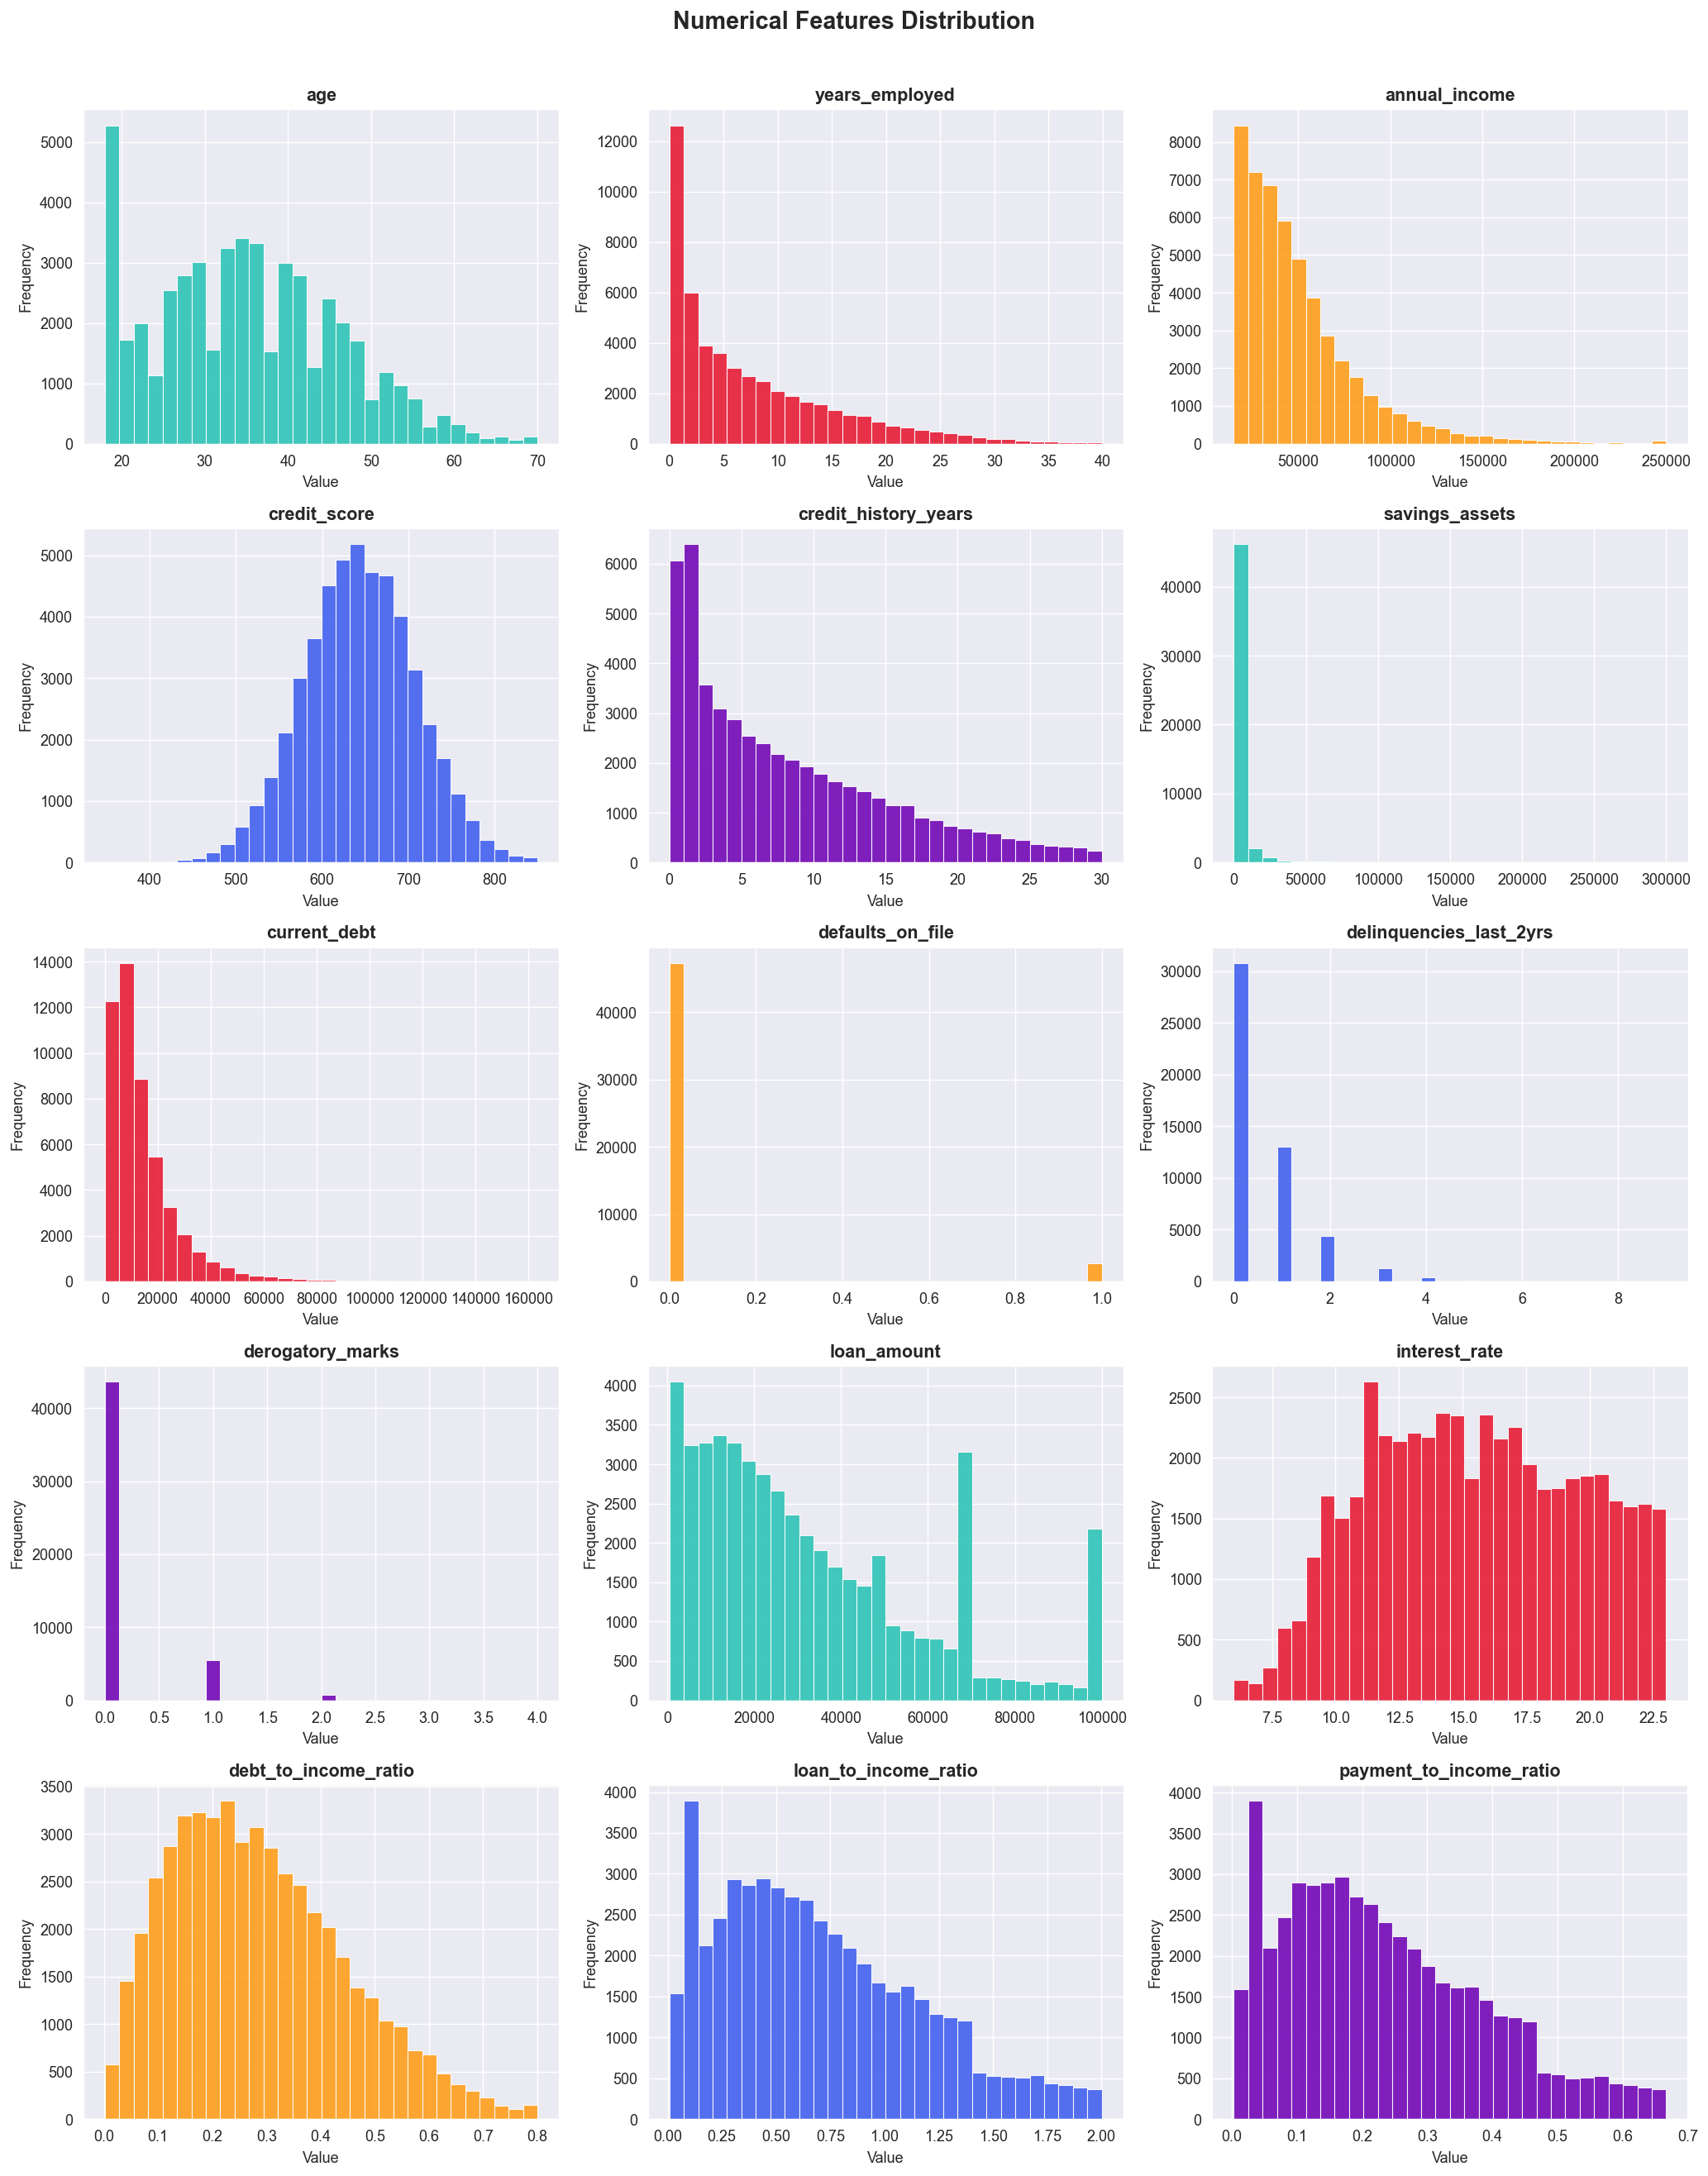

In [60]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
if target_col in num_cols :
    num_cols.remove(target_col)
    
n = len(num_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30,
                 color=PALETTE[i % len(PALETTE)],
                 edgecolor="white", linewidth=0.6, alpha=0.9)
    axes[i].set_title(col, fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Value", fontsize=10)
    axes[i].set_ylabel("Frequency", fontsize=10)
    
for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

plt.suptitle("Numerical Features Distribution", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Eda Insights
From EDA, I observed that most financial features like income, assets, and debt are heavily right-skewed, indicating a few high-value outliers. Key predictive features such as credit score showed a near-normal distribution, while rare-event features like defaults and derogatory marks were highly imbalanced but critical for risk assessment. Based on this, I applied log transformations and outlier capping to improve model stability.

# Log Transformation to highly skewed features

In [61]:
skewed_cols = [
    "annual_income",
    "savings_assets",
    "current_debt",
    "loan_amount"
]

for col in skewed_cols:
    df[col] = np.log1p(df[col])

# Convert to clean Binary

In [62]:
df["derogatory_marks"].value_counts()


derogatory_marks
0    43607
1     5524
2      758
3      102
4        9
Name: count, dtype: int64

In [63]:
df["has_derog"] = (df["derogatory_marks"] > 0).astype(int)
df["has_derog"].value_counts()


has_derog
0    43607
1     6393
Name: count, dtype: int64

In [64]:
df.drop(columns=["derogatory_marks"], axis=1, inplace=True)

# Categorical Features Distribution and Target Analysis

Categorical Columns: ['occupation_status', 'product_type', 'loan_intent']


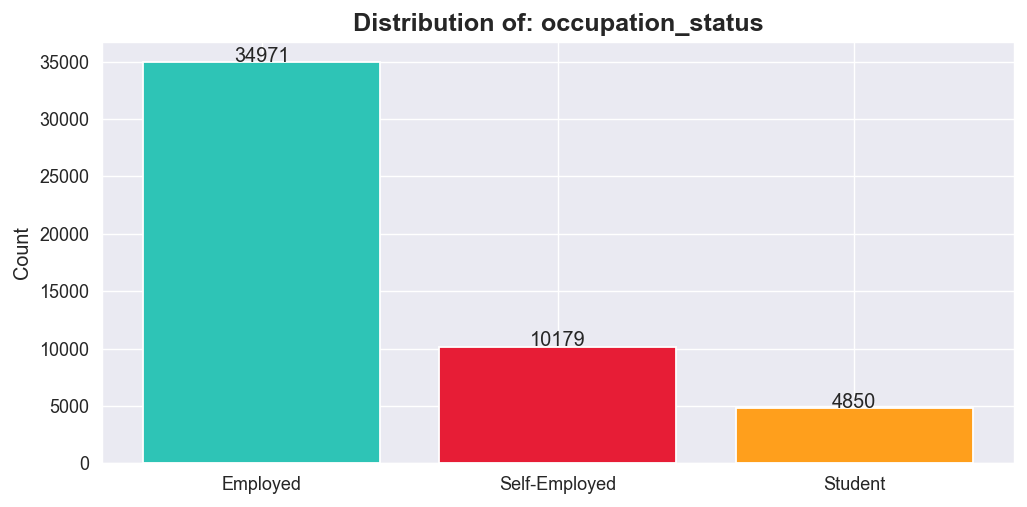

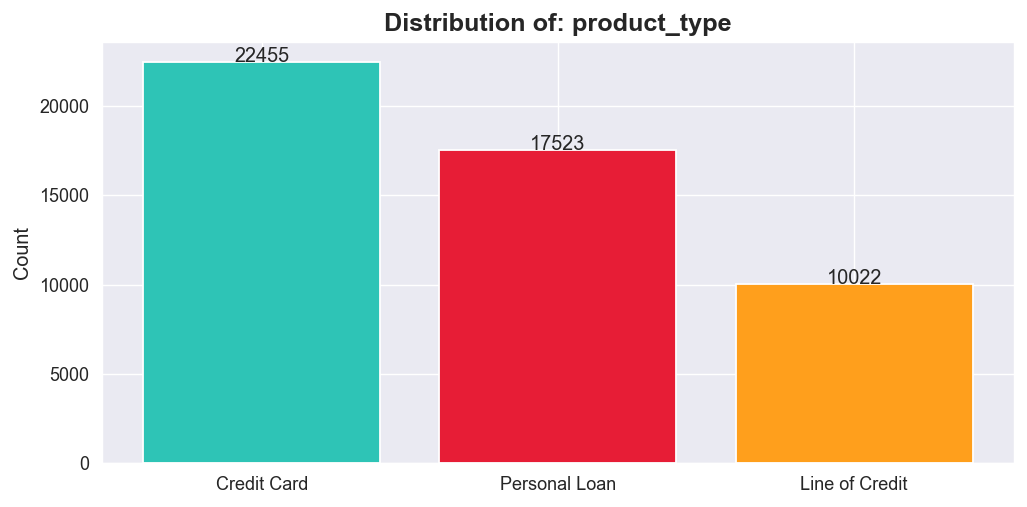

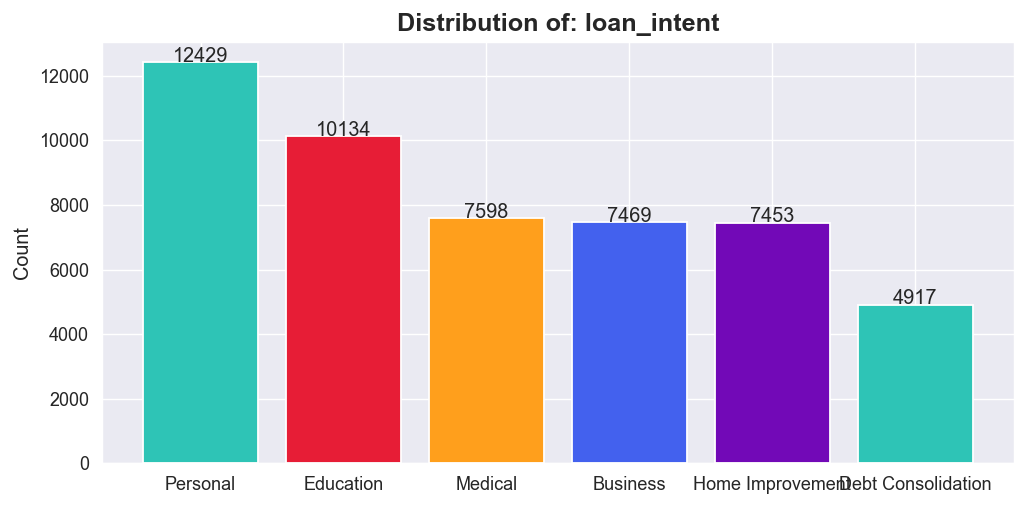

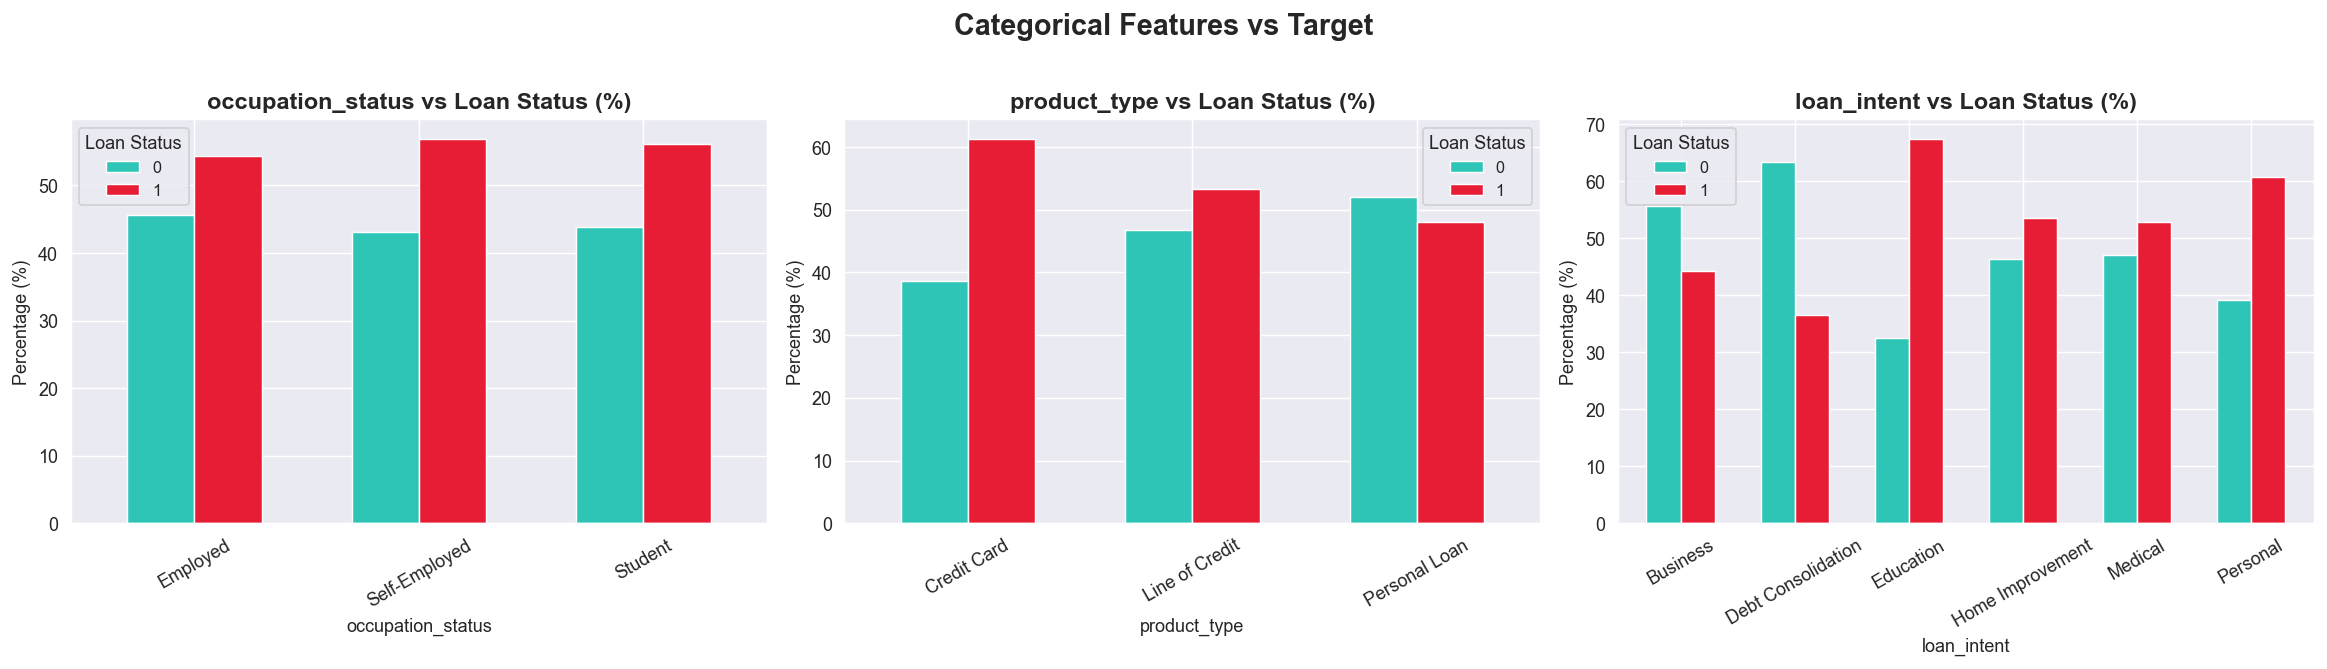

In [65]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
if target_col in cat_cols:
    cat_cols.remove(target_col)

print("Categorical Columns:", cat_cols)

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(counts.index, counts.values,
                  color=PALETTE[:len(counts)], edgecolor="white", linewidth=1)
    ax.set_title(f"Distribution of: {col}", fontsize=14, fontweight="bold")
    ax.set_ylabel("Count", fontsize=11)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 5,
                str(int(bar.get_height())),
                ha="center", fontsize=11)
    plt.tight_layout()
    plt.show()

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 5))

if len(cat_cols) == 1:
    axes = [axes]
    
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df[target_col], normalize="index") * 100
    ct.plot(kind="bar", ax=axes[i],
            color=[PALETTE[0], PALETTE[1]],
            edgecolor="white", linewidth=0.8, width=0.6)
    axes[i].set_title(f"{col} vs Loan Status (%)", fontsize=13, fontweight="bold")
    axes[i].set_ylabel("Percentage (%)", fontsize=10)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30)
    axes[i].legend(title="Loan Status", fontsize=9)

plt.suptitle("Categorical Features vs Target", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

I analyzed categorical features using normalized cross-tabulation to understand their relationship with loan approval. This helped identify which categories significantly influenced approval decisions.

# Outlier Visualization (Boxplots)

In [69]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

if target_col in num_cols:
    num_cols.remove(target_col)

print(num_cols)

['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio', 'has_derog']


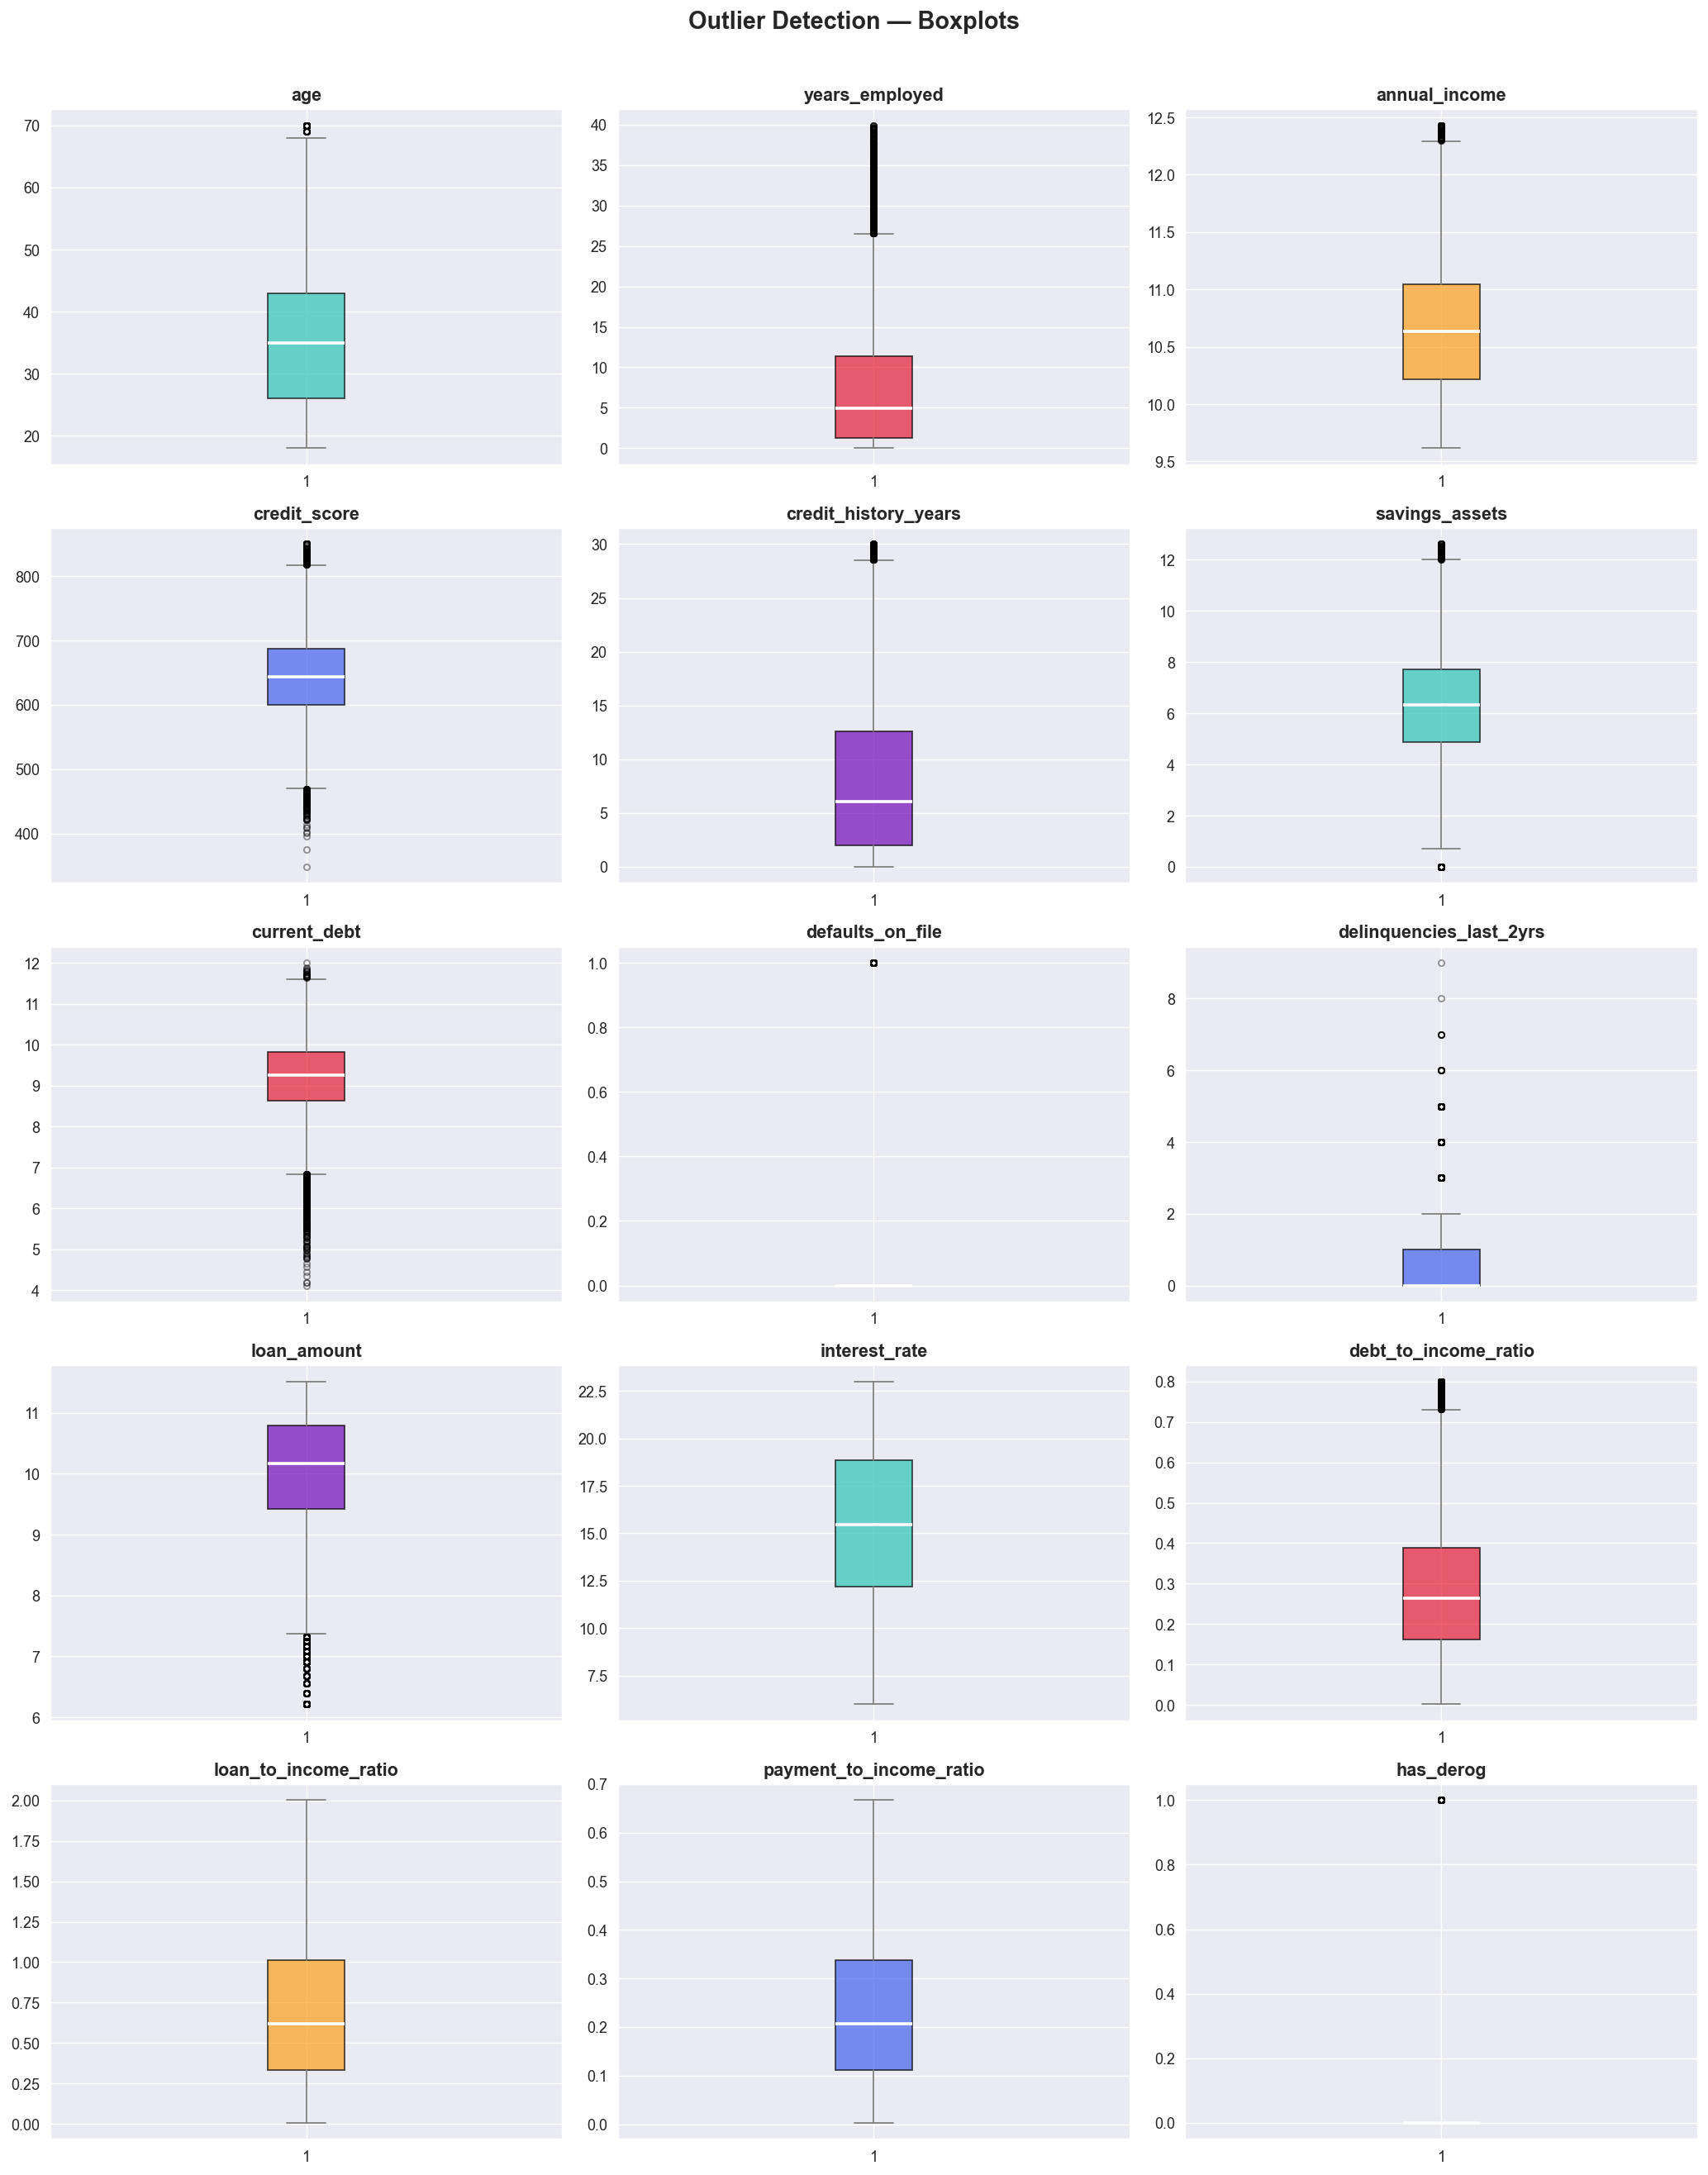

In [70]:
fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=PALETTE[i % len(PALETTE)], alpha=0.7),
                    medianprops=dict(color="white", linewidth=2),
                    whiskerprops=dict(color="gray"),
                    capprops=dict(color="gray"),
                    flierprops=dict(marker="o", color=PALETTE[1], alpha=0.4, markersize=4))
    axes[i].set_title(col, fontsize=12, fontweight="bold")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Outlier Detection — Boxplots", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

The boxplots show that several financial features contain extreme values, especially debt, loan amount, income-related variables, and employment history. Many of these are right-skewed financial variables, so the extreme points are likely genuine high-value applicants rather than data errors. Rare-event variables like defaults and derogatory marks appear as outliers in boxplots, but they should be retained because they carry strong credit-risk information.

# Capping 
This keeps data but reduces the impact of extreme tails.

In [71]:
cap_cols = ["annual_income", "savings_assets", "current_debt", "loan_amount"]

for col in cap_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

Log transformation reduced skewness and scaled down extreme values, but did not eliminate outliers completely, since financial data is naturally heavy-tailed. I further handled extreme values using quantile-based capping.

# Correlation Heatmap

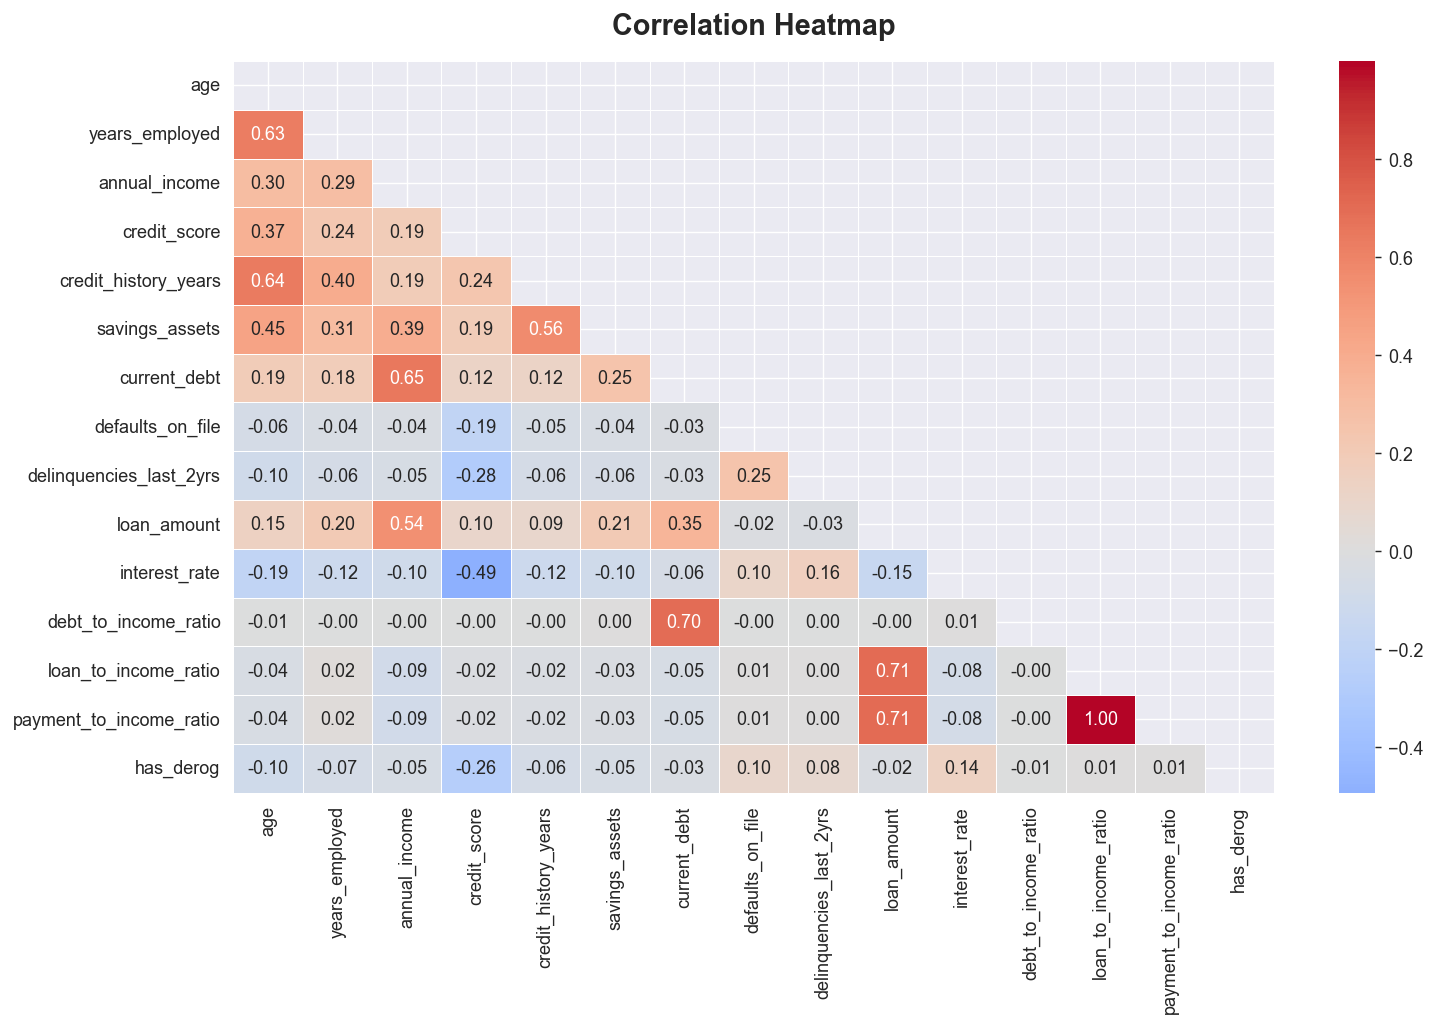

In [72]:
fig, ax = plt.subplots(figsize=(12, 8))

corr_matrix = df[num_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5,
            linecolor="white", ax=ax,
            annot_kws={"size": 10})

ax.set_title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

A near-perfect correlation (~1.0) between payment_to_income_ratio and loan_to_income_ratio indicates feature redundancy, so one was removed to avoid multicollinearity.


In [73]:
df.drop("loan_to_income_ratio", axis=1, inplace=True)

# Encode Categorical Features

In [74]:
df_model = df.copy()

from sklearn.preprocessing import LabelEncoder

for col in df_model.select_dtypes(include="object").columns:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

# Feature Engineering

In [81]:
df_model["net_worth"] = df_model["savings_assets"] - df_model["current_debt"]

# Split feature and target

In [82]:
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print("Target classes:", y.unique())

Features shape: (50000, 18)
Target shape  : (50000,)
Target classes: [1 0]


# Train Test Split

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

Training set : (40000, 18)
Test set     : (10000, 18)


# Scalling

In [84]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Multiple Models

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced"
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

results = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():

    if name == "Logistic Regression":
        X_tr, X_te = X_train_scaled, X_test_scaled
    else:
        X_tr, X_te = X_train, X_test

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)

    cv = cross_val_score(
        model,
        X_tr,
        y_train,
        cv=cv_strategy,
        scoring="accuracy",
        n_jobs=-1
    )

    results[name] = {
        "model": model,
        "test_acc": acc,
        "cv_mean": cv.mean(),
        "cv_std": cv.std(),
        "y_pred": y_pred
    }

    print(f"{name:<25} Test: {acc:.4f}  CV: {cv.mean():.4f} +/- {cv.std():.4f}")

Logistic Regression       Test: 0.8553  CV: 0.8583 +/- 0.0035
Decision Tree             Test: 0.8532  CV: 0.8543 +/- 0.0006
Random Forest             Test: 0.8874  CV: 0.8874 +/- 0.0024
Gradient Boosting         Test: 0.9117  CV: 0.9151 +/- 0.0034


# Hyperparameter Tuning — Optimized Ensemble Models

In [89]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

tuned_models = {
    "Random Forest Tuned": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting Tuned": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        random_state=42
    )
}

tuned_results = {}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in tuned_models.items():
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    cv = cross_val_score(
        model,
        X_tr,
        y_train,
        cv=cv_strategy,
        scoring="accuracy",
        n_jobs=-1
    )

    tuned_results[name] = {
        "model": model,
        "test_acc": acc,
        "cv_mean": cv.mean(),
        "cv_std": cv.std(),
        "y_pred": y_pred
    }

    print(f"{name:<25} Test: {acc:.4f}  CV: {cv.mean():.4f} +/- {cv.std():.4f}")

Random Forest Tuned       Test: 0.9022  CV: 0.9045 +/- 0.0032
Gradient Boosting Tuned   Test: 0.9222  CV: 0.9249 +/- 0.0026


# Advanced Model — XGBoost Implementation & Evaluation

In [90]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# Cross-validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)


xgb_result = {
    "XGBoost": {
        "model": xgb,
        "test_acc": acc,
        "cv_mean": cv.mean(),
        "cv_std": cv.std(),
        "y_pred": y_pred
    }
}

print(f"XGBoost                  Test: {acc:.4f}  CV: {cv.mean():.4f} +/- {cv.std():.4f}")

XGBoost                  Test: 0.9258  CV: 0.9287 +/- 0.0017


# Model Comparision Chart

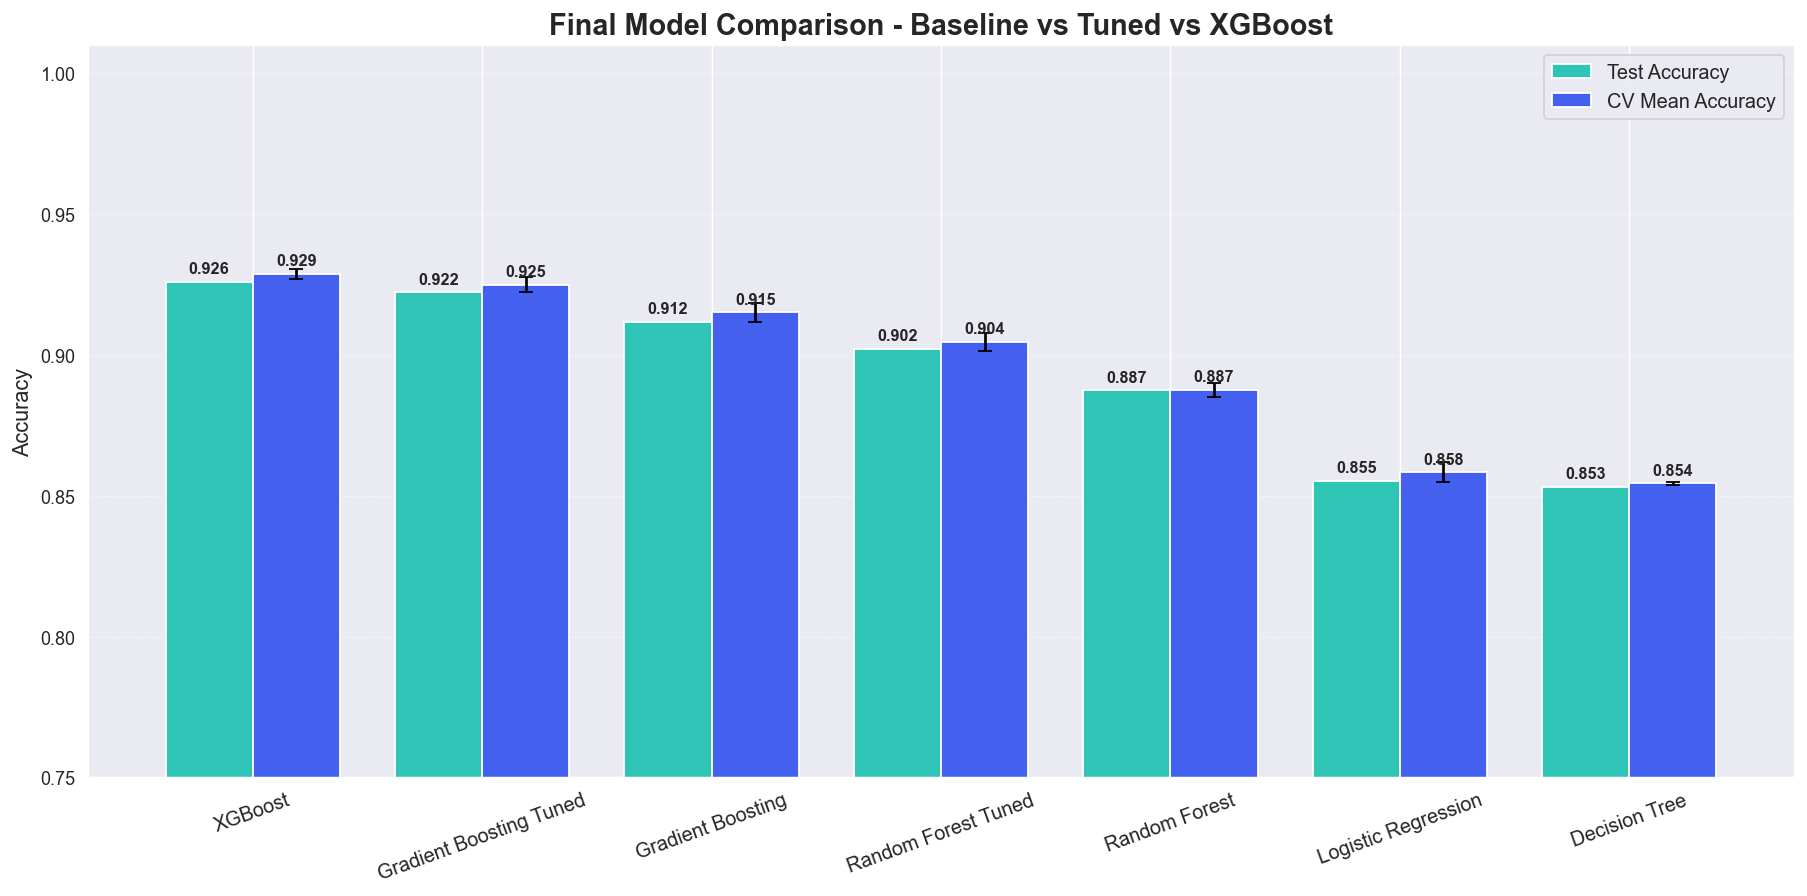

In [91]:


# Combine all model results
all_results = {}
all_results.update(results)         # baseline
all_results.update(tuned_results)   # tuned
all_results.update(xgb_result)      # xgboost

# Sort by CV mean accuracy
names = sorted(all_results.keys(), key=lambda n: all_results[n]["cv_mean"], reverse=True)

test_acc = [all_results[n]["test_acc"] for n in names]
cv_mean  = [all_results[n]["cv_mean"] for n in names]
cv_std   = [all_results[n]["cv_std"] for n in names]

x = np.arange(len(names))
width = 0.38

fig, ax = plt.subplots(figsize=(14, 7))

bars1 = ax.bar(
    x - width/2,
    test_acc,
    width,
    label="Test Accuracy",
    color=PALETTE[0],
    edgecolor="white",
    linewidth=1
)

bars2 = ax.bar(
    x + width/2,
    cv_mean,
    width,
    yerr=cv_std,
    capsize=4,
    label="CV Mean Accuracy",
    color=PALETTE[3],
    edgecolor="white",
    linewidth=1
)

# Add score labels
for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f"{bar.get_height():.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, fontsize=11)
ax.set_ylim(0.75, 1.01)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Final Model Comparison - Baseline vs Tuned vs XGBoost", fontsize=16, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Best Model

In [92]:
# Combine all results
all_results = {}
all_results.update(results)
all_results.update(tuned_results)
all_results.update(xgb_result)

# Find best model based on CV mean
best_name = max(all_results, key=lambda n: all_results[n]["cv_mean"])
best      = all_results[best_name]
best_model = best["model"]

print(f"Best Model : {best_name}")
print(f"Test Acc   : {best['test_acc']:.4f}")
print(f"CV Mean    : {best['cv_mean']:.4f} +/- {best['cv_std']:.4f}")

Best Model : XGBoost
Test Acc   : 0.9258
CV Mean    : 0.9287 +/- 0.0017


# Classification Resport

In [93]:
print("=" * 55)
print(f"CLASSIFICATION REPORT — {best_name}")
print("=" * 55)
print(classification_report(y_test, best["y_pred"]))

CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

           0       0.93      0.90      0.92      4495
           1       0.92      0.94      0.93      5505

    accuracy                           0.93     10000
   macro avg       0.93      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



The XGBoost model achieved ~93% accuracy with balanced precision and recall across both approval and rejection classes. The model demonstrates strong generalization with minimal overfitting, as indicated by consistent cross-validation scores.

It effectively identifies both creditworthy applicants and high-risk borrowers, making it suitable for real-world loan approval systems. Further improvements can be achieved through feature engineering and threshold optimization based on business risk preferences.

# Confusion Matrix

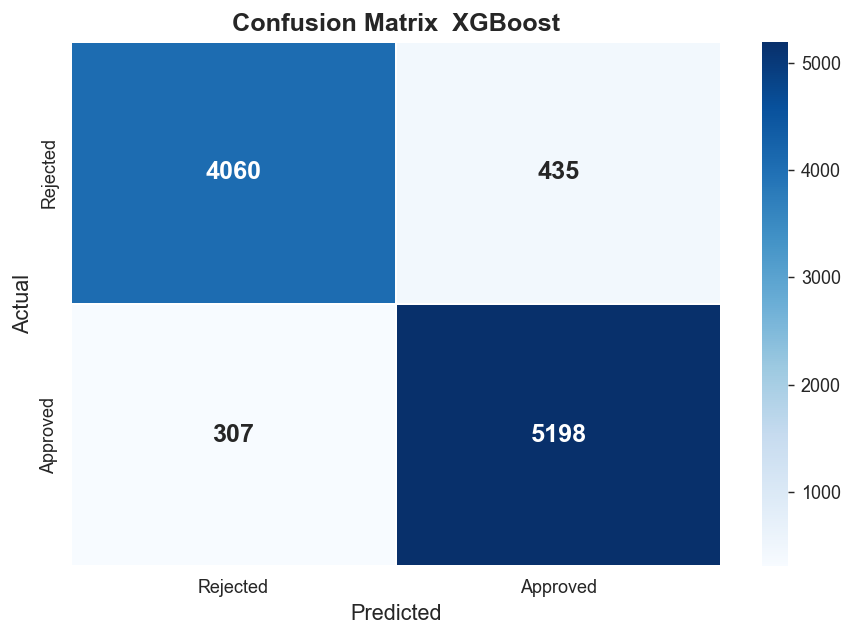

In [94]:
cm = confusion_matrix(y_test, best["y_pred"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"],
            linewidths=1, linecolor="white",
            annot_kws={"size": 14, "weight": "bold"})
ax.set_title(f"Confusion Matrix  {best_name}", fontsize=14, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)
plt.tight_layout()
plt.show()

The confusion matrix shows that the model correctly classifies the majority of both approved and rejected applications, achieving high true positive and true negative rates. While a small number of risky applicants are incorrectly approved, the model maintains a strong balance between minimizing financial risk and maximizing business opportunity.

# ROC Curve

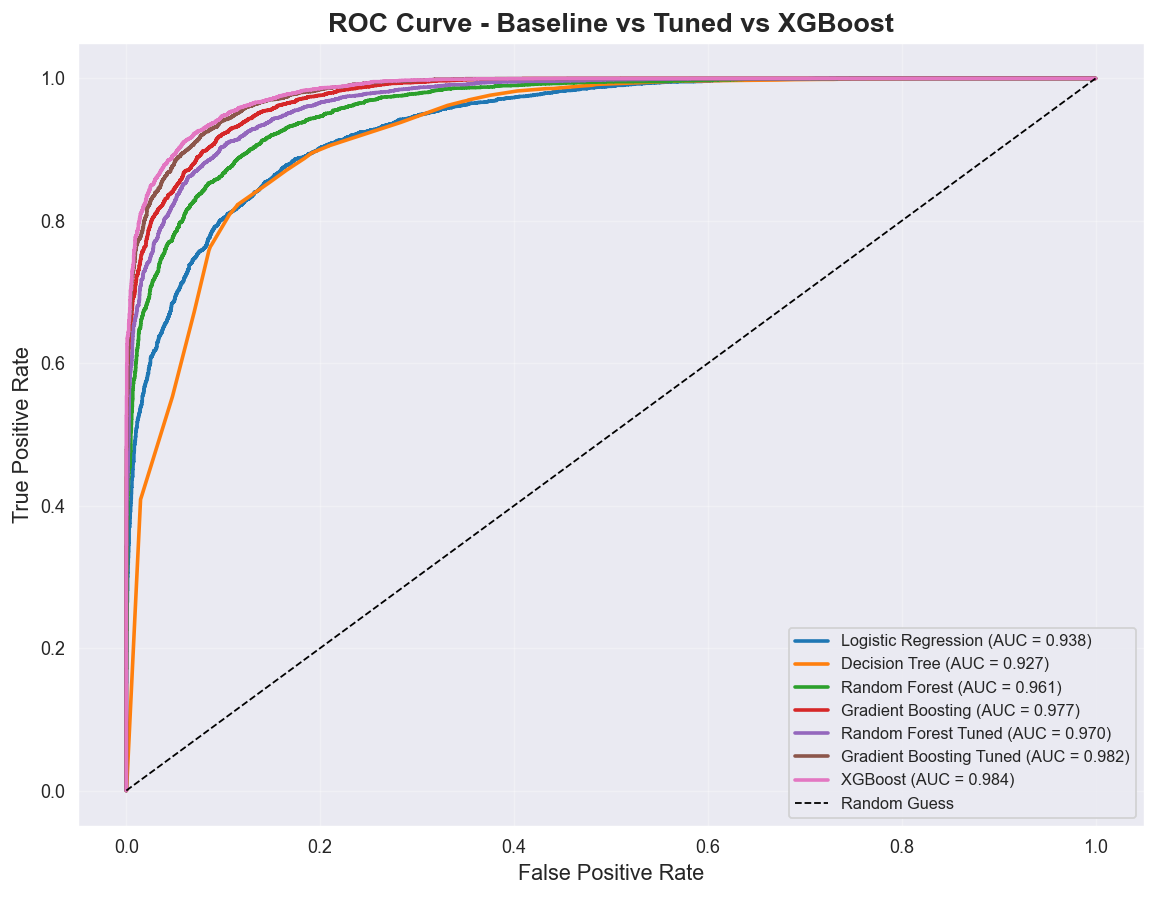

In [95]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

all_results = {}
all_results.update(results)
all_results.update(tuned_results)
all_results.update(xgb_result)

fig, ax = plt.subplots(figsize=(9, 7))

for name, res in all_results.items():
    model = res["model"]

    # Only Logistic Regression uses scaled data
    if name == "Logistic Regression":
        X_te = X_test_scaled
    else:
        X_te = X_test

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)

        ax.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random Guess")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve - Baseline vs Tuned vs XGBoost", fontsize=15, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The ROC curve analysis shows that all models achieve strong classification performance, with AUC values above 0.92. Ensemble models significantly outperform baseline models, with Gradient Boosting and XGBoost achieving near-optimal performance. While XGBoost achieves the highest AUC (0.984), the marginal improvement over tuned Gradient Boosting suggests diminishing returns, indicating that further gains depend more on feature engineering than model complexity.

# Feature Importance

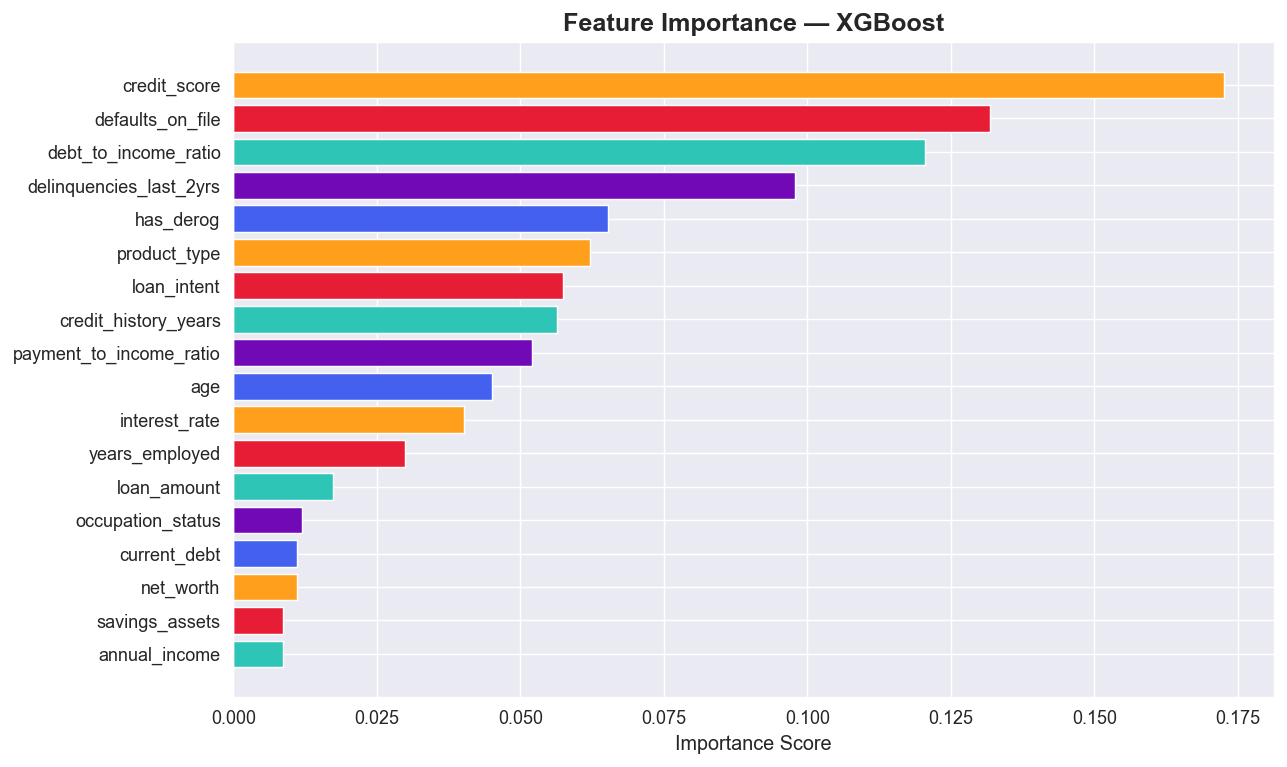

In [96]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(importances.index, importances.values,
            color=[PALETTE[i % len(PALETTE)] for i in range(len(importances))],
            edgecolor="white", linewidth=0.8)
    ax.set_title(f"Feature Importance — {best_name}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Importance Score", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model type.")

Feature importance analysis shows that credit score, default history, and debt-related ratios are the most influential factors in loan approval decisions. The model prioritizes financial behavior and repayment capacity over absolute income, aligning with real-world lending practices.

# Overfitting Check

In [104]:
print("\n" + "=" * 60)
print("OVERFITTING CHECK - FINAL MODELS")
print("=" * 60)

all_results = {}
all_results.update(results)
all_results.update(tuned_results)
all_results.update(xgb_result)

for name, res in all_results.items():
    model = res["model"]

    if name == "Logistic Regression":
        X_tr = X_train_scaled
    else:
        X_tr = X_train

    train_acc = accuracy_score(y_train, model.predict(X_tr))
    test_acc  = res["test_acc"]
    gap       = train_acc - test_acc

    if train_acc < 0.85 and test_acc < 0.85:
        status = "UNDERFIT"   # both low → model too simple

    elif train_acc >= 0.85 and gap > 0.05:
        status = "OVERFIT"    # good on train, drops on test

    elif train_acc >= 0.85 and gap <= 0.05:
        status = "GOOD"       # high and stable

    print(f"{name:<30} Train: {train_acc:.4f}  Test: {test_acc:.4f}  Gap: {gap:.4f}  [{status}]")


OVERFITTING CHECK - FINAL MODELS
Logistic Regression            Train: 0.8582  Test: 0.8553  Gap: 0.0029  [GOOD]
Decision Tree                  Train: 0.8574  Test: 0.8532  Gap: 0.0042  [GOOD]
Random Forest                  Train: 0.8976  Test: 0.8874  Gap: 0.0102  [GOOD]
Gradient Boosting              Train: 0.9182  Test: 0.9117  Gap: 0.0065  [GOOD]
Random Forest Tuned            Train: 0.9426  Test: 0.9022  Gap: 0.0404  [GOOD]
Gradient Boosting Tuned        Train: 0.9302  Test: 0.9222  Gap: 0.0080  [GOOD]
XGBoost                        Train: 0.9444  Test: 0.9258  Gap: 0.0186  [GOOD]


# Create Sample Application

In [105]:
sample_applicants = pd.DataFrame({
    "age": [42, 35, 24, 50, 29],
    "years_employed": [12, 6, 1, 20, 3],
    "annual_income": [180000, 85000, 32000, 140000, 50000],
    "credit_score": [780, 670, 480, 820, 560],
    "credit_history_years": [15, 8, 2, 22, 4],
    "savings_assets": [90000, 30000, 5000, 120000, 10000],
    "current_debt": [15000, 25000, 18000, 10000, 30000],
    "defaults_on_file": [0, 0, 1, 0, 0],
    "delinquencies_last_2yrs": [0, 1, 3, 0, 2],
    "has_derog": [0, 0, 1, 0, 0],
    "occupation_status": [2, 1, 0, 2, 1],
    "product_type": [1, 0, 2, 1, 0],
    "loan_intent": [0, 2, 1, 3, 4],
    "loan_amount": [40000, 25000, 18000, 50000, 22000],
    "interest_rate": [9.5, 12.8, 18.5, 8.2, 15.6],
    "debt_to_income_ratio": [0.18, 0.32, 0.58, 0.12, 0.45],
    "payment_to_income_ratio": [0.11, 0.24, 0.41, 0.09, 0.33]
})

# feature engineered column
sample_applicants["net_worth"] = (
    sample_applicants["savings_assets"] - sample_applicants["current_debt"]
)

applicant_names = [
    "Applicant A - Strong Profile",
    "Applicant B - Moderate Risk",
    "Applicant C - High Risk",
    "Applicant D - Premium Borrower",
    "Applicant E - Borderline Case"
]

print("Sample applicants created.")
sample_applicants

Sample applicants created.


,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,has_derog,occupation_status,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,payment_to_income_ratio,net_worth
0,42,12,180000,780,15,90000,15000,0,0,0,2,1,0,40000,9.5,0.18,0.11,75000
1,35,6,85000,670,8,30000,25000,0,1,0,1,0,2,25000,12.8,0.32,0.24,5000
2,24,1,32000,480,2,5000,18000,1,3,1,0,2,1,18000,18.5,0.58,0.41,-13000
3,50,20,140000,820,22,120000,10000,0,0,0,2,1,3,50000,8.2,0.12,0.09,110000
4,29,3,50000,560,4,10000,30000,0,2,0,1,0,4,22000,15.6,0.45,0.33,-20000


In [106]:
# Make sure column order matches training data
sample_applicants = sample_applicants[X_train.columns]

# Use final model directly (XGBoost / tree-based model)
final_name = "XGBoost"
final_model = xgb_result[final_name]["model"]

predictions   = final_model.predict(sample_applicants)
probabilities = final_model.predict_proba(sample_applicants)

prob_approved = [f"{p[1] * 100:.1f}%" for p in probabilities]
prob_rejected = [f"{p[0] * 100:.1f}%" for p in probabilities]
decision      = ["APPROVED" if p == 1 else "REJECTED" for p in predictions]

results_df = pd.DataFrame({
    "Applicant"              : applicant_names,
    "Annual Income"          : [f"{v:,}" for v in sample_applicants["annual_income"]],
    "Loan Amount"            : [f"{v:,}" for v in sample_applicants["loan_amount"]],
    "Credit Score"           : sample_applicants["credit_score"].values,
    "Debt-to-Income Ratio"   : sample_applicants["debt_to_income_ratio"].values,
    "Prob Approved"          : prob_approved,
    "Prob Rejected"          : prob_rejected,
    "Decision"               : decision
})

def color_decision(val):
    if val == "APPROVED":
        return "background-color: #2EC4B6; color: white; font-weight: bold; text-align: center"
    else:
        return "background-color: #E71D36; color: white; font-weight: bold; text-align: center"

def color_credit(val):
    if val >= 750:
        return "background-color: #c8f7c5; color: #1a7a16; font-weight: bold"
    elif val >= 600:
        return "background-color: #fff3cd; color: #856404; font-weight: bold"
    else:
        return "background-color: #ffd6d6; color: #b30000; font-weight: bold"

styled = (
    results_df.style
    .map(color_decision, subset=["Decision"])
    .map(color_credit, subset=["Credit Score"])
    .set_table_styles([
        {"selector": "thead th",
         "props": [("background-color", "#4361EE"),
                   ("color", "white"),
                   ("font-size", "13px"),
                   ("text-align", "center"),
                   ("padding", "10px")]},
        {"selector": "tbody td",
         "props": [("text-align", "center"),
                   ("padding", "9px"),
                   ("font-size", "12px")]},
        {"selector": "tbody tr:nth-child(even)",
         "props": [("background-color", "#f5f5f5")]}
    ])
    .set_caption("Loan Approval Prediction Results - Sample Applicants")
    .hide(axis="index")
)

styled

Applicant,Annual Income,Loan Amount,Credit Score,Debt-to-Income Ratio,Prob Approved,Prob Rejected,Decision
Applicant A - Strong Profile,"180,000","40,000",780,0.180000,99.9%,0.1%,APPROVED
Applicant B - Moderate Risk,"85,000","25,000",670,0.320000,99.9%,0.1%,APPROVED
Applicant C - High Risk,"32,000","18,000",480,0.580000,0.0%,100.0%,REJECTED
Applicant D - Premium Borrower,"140,000","50,000",820,0.120000,100.0%,0.0%,APPROVED
Applicant E - Borderline Case,"50,000","22,000",560,0.450000,1.1%,98.9%,REJECTED
